# Task 2: Customer Segmentation

## Selecting Data for Modeling

In [3]:
import gdown
import pandas as pd

url = "https://drive.google.com/uc?id=1nAC7hE8gRm6NYcYw1aPE9i4_4cz-XVGM"
Mall_Customers_file_path = "Mall_Customers.csv"
gdown.download(url, Mall_Customers_file_path, quiet=False)

df = pd.read_csv(Mall_Customers_file_path)
df.columns

Downloading...
From: https://drive.google.com/uc?id=1nAC7hE8gRm6NYcYw1aPE9i4_4cz-XVGM
To: c:\Users\user\Desktop\Elevvo ML Internship Program\materials\4- Your First ML Model\Mall_Customers.csv
100%|██████████| 4.29k/4.29k [00:00<00:00, 61.8kB/s]


Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [4]:
print(df.shape)
print(df.head())

(200, 5)
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


# Choosing "Features"

By convention, this data is called **X**.

In [6]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

📌 Let's quickly review the data we'll be using to customer segmentation using the `describe` method and the `head` method, which shows the top few rows.

In [7]:
X.describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


In [8]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [9]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


c:\Users\user\.conda\envs\cvproject\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\.conda\envs\cvproject\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\.conda\envs\cvproject\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\.conda\envs\cvproject\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMe

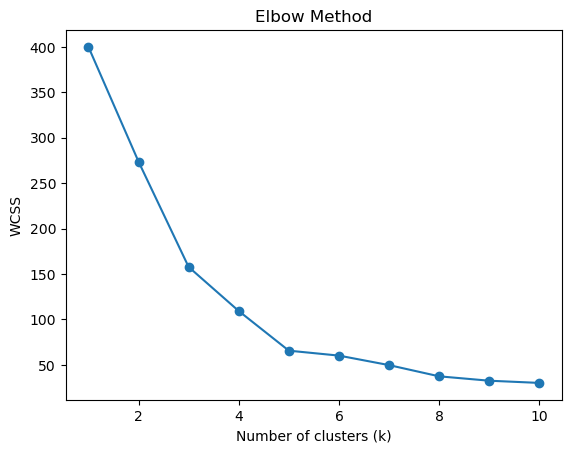

In [10]:
# Clusters (Elbow Method)
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [11]:
# KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters


c:\Users\user\.conda\envs\cvproject\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


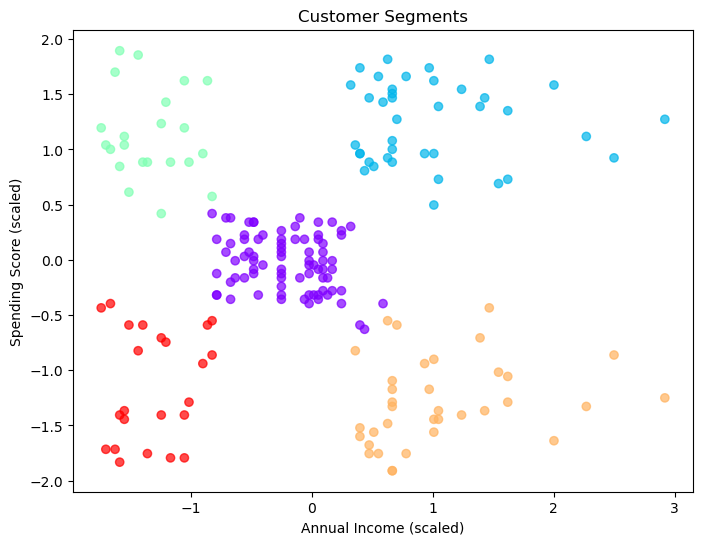

In [12]:
# Visualization
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap="rainbow", alpha=0.7)
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Customer Segments")
plt.show()



In [13]:
print(df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean())

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [14]:
from sklearn.metrics import silhouette_score
silhouette_score(X_scaled, clusters)


0.5546571631111091